# Baseline Simulation (No MAB)

Simulate 30 rounds × 5 000 transactions using the original listing prices (no arm selection).  
Reward per transaction = predicted booking probability × price_listing.  
Results are saved to `results/baseline_results.csv` for later comparison with MAB strategies.

## 1. Imports & Configuration

In [9]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────
BASE_DIR   = os.path.dirname(os.getcwd())
DATA_PATH  = os.path.join(BASE_DIR, 'data',   'processed_data.csv')
MODEL_PATH = os.path.join(BASE_DIR, 'model',  'lgbm_model.pkl')
RESULT_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

# ── Simulation parameters ─────────────────────────────────────────────
N_ROUNDS       = 30
N_TRANSACTIONS = 50_000
N_TIERS        = 4      # price tiers 0–3 (Budget / Standard / Premium / Luxury)
SEED_BASE      = 42     # round r uses seed = SEED_BASE + r  → fully reproducible

TIER_LABELS = {
    0: 'Budget (≤100)',
    1: 'Standard (101–300)',
    2: 'Premium (301–600)',
    3: 'Luxury (601–2000)',
}
TIER_COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

print(f'Transactions per round : {N_TRANSACTIONS:,}')
print(f'Total rounds           : {N_ROUNDS}')

Transactions per round : 50,000
Total rounds           : 30


## 2. Load Model & Data

In [10]:
# Load trained LightGBM model
saved    = joblib.load(MODEL_PATH)
model    = saved['model']
features = saved['features']
print(f'Model loaded  |  {len(features)} features')

# Load processed data
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Data loaded   |  shape: {df.shape}  |  booking rate: {df["booked"].mean():.2%}')

# Verify price_tier coverage
tier_counts = df['price_tier'].value_counts().sort_index()
print('\nPrice tier distribution in full dataset:')
for t, cnt in tier_counts.items():
    print(f'  Tier {t} {TIER_LABELS[t]:22s}: {cnt:>8,} rows  ({cnt/len(df):.1%})')

# Drop rows without a valid price_tier (safety check)
df = df.dropna(subset=['price_tier']).copy()
df['price_tier'] = df['price_tier'].astype(int)

Model loaded  |  17 features
Data loaded   |  shape: (953380, 19)  |  booking rate: 17.00%

Price tier distribution in full dataset:
  Tier 0 Budget (≤100)         :  264,625 rows  (27.8%)
  Tier 1 Standard (101–300)    :  370,110 rows  (38.8%)
  Tier 2 Premium (301–600)     :  236,520 rows  (24.8%)
  Tier 3 Luxury (601–2000)     :   82,125 rows  (8.6%)


## 3. Sampling Strategy

Each round draws **5 000 rows stratified by `price_tier` in proportion to the tier's share
in the full dataset** (mirrors the real listing distribution).  

Reproducibility is guaranteed by `random_state = SEED_BASE + round_idx`: any MAB notebook
that uses the same seed scheme will draw the **exact same rows per tier**, making reward
comparisons fair.

In [11]:
# Pre-split data by tier for fast stratified sampling
tier_pools = {
    t: df[df['price_tier'] == t].reset_index(drop=True)
    for t in range(N_TIERS)
}

# Compute proportional sample counts (sum = N_TRANSACTIONS exactly)
total_rows  = sum(len(p) for p in tier_pools.values())
tier_props  = {t: len(p) / total_rows for t, p in tier_pools.items()}

# Allocate counts proportionally; give any rounding remainder to the largest tier
tier_ns = {t: int(np.floor(tier_props[t] * N_TRANSACTIONS)) for t in range(N_TIERS)}
remainder = N_TRANSACTIONS - sum(tier_ns.values())
largest_tier = max(tier_props, key=tier_props.get)
tier_ns[largest_tier] += remainder

print('Proportional sample counts per round:')
for t in range(N_TIERS):
    print(f'  Tier {t} {TIER_LABELS[t]:22s}: {tier_ns[t]:4d}  ({tier_props[t]:.1%} of pool)')


def sample_round(tier_pools, tier_ns, features, model, round_idx):
    """
    Draw tier_ns[t] rows from each price tier using seed = SEED_BASE + round_idx.
    Proportions mirror the real dataset distribution.
    Returns a DataFrame with columns: price_tier, price_listing, pred_prob, reward.
    """
    seed   = SEED_BASE + round_idx
    frames = []

    for t, pool in tier_pools.items():
        sample = pool.sample(n=tier_ns[t], replace=True, random_state=seed)
        frames.append(sample)

    batch = pd.concat(frames, ignore_index=True)

    # Predict booking probability using the original price features
    X_batch = batch[features]
    batch['pred_prob'] = model.predict_proba(X_batch)[:, 1]

    # Reward = expected revenue for this transaction
    batch['reward'] = batch['pred_prob'] * batch['price_listing']

    return batch[['price_tier', 'price_listing', 'pred_prob', 'reward']]

Proportional sample counts per round:
  Tier 0 Budget (≤100)         : 13878  (27.8% of pool)
  Tier 1 Standard (101–300)    : 19411  (38.8% of pool)
  Tier 2 Premium (301–600)     : 12404  (24.8% of pool)
  Tier 3 Luxury (601–2000)     : 4307  (8.6% of pool)


## 4. Baseline Simulation Loop

In [12]:
records       = []   # one row per round summary
all_round_dfs = []   # full transaction log (for detailed analysis)

for r in range(N_ROUNDS):
    batch = sample_round(tier_pools, tier_ns, features, model, round_idx=r)

    # Per-tier sample counts
    tier_sample_counts = batch['price_tier'].value_counts().sort_index().to_dict()

    # Per-tier reward
    tier_rewards = batch.groupby('price_tier')['reward'].sum().to_dict()

    total_reward = batch['reward'].sum()
    avg_prob     = batch['pred_prob'].mean()

    record = {
        'round'        : r + 1,
        'total_reward' : total_reward,
        'avg_pred_prob': avg_prob,
    }
    for t in range(N_TIERS):
        record[f'n_tier_{t}']      = tier_sample_counts.get(t, 0)
        record[f'reward_tier_{t}'] = tier_rewards.get(t, 0.0)

    records.append(record)

    # Tag the batch with round index for the full log
    batch['round'] = r + 1
    all_round_dfs.append(batch)

    print(f'Round {r+1:2d}/30 | reward: {total_reward:>10,.1f} | '
          f'avg P(book): {avg_prob:.4f} | '
          f'tier counts: {[tier_sample_counts.get(t, 0) for t in range(N_TIERS)]}')

results_df = pd.DataFrame(records)
full_log   = pd.concat(all_round_dfs, ignore_index=True)
print(f'\nSimulation complete. Mean total reward per round: {results_df["total_reward"].mean():,.1f}')

Round  1/30 | reward: 3,415,326.2 | avg P(book): 0.2539 | tier counts: [13878, 19411, 12404, 4307]
Round  2/30 | reward: 3,420,016.9 | avg P(book): 0.2541 | tier counts: [13878, 19411, 12404, 4307]
Round  3/30 | reward: 3,441,560.2 | avg P(book): 0.2554 | tier counts: [13878, 19411, 12404, 4307]
Round  4/30 | reward: 3,409,335.3 | avg P(book): 0.2552 | tier counts: [13878, 19411, 12404, 4307]
Round  5/30 | reward: 3,393,323.7 | avg P(book): 0.2520 | tier counts: [13878, 19411, 12404, 4307]
Round  6/30 | reward: 3,477,713.9 | avg P(book): 0.2573 | tier counts: [13878, 19411, 12404, 4307]
Round  7/30 | reward: 3,420,404.0 | avg P(book): 0.2547 | tier counts: [13878, 19411, 12404, 4307]
Round  8/30 | reward: 3,430,002.1 | avg P(book): 0.2541 | tier counts: [13878, 19411, 12404, 4307]
Round  9/30 | reward: 3,422,916.2 | avg P(book): 0.2533 | tier counts: [13878, 19411, 12404, 4307]
Round 10/30 | reward: 3,464,374.8 | avg P(book): 0.2545 | tier counts: [13878, 19411, 12404, 4307]
Round 11/3

## 5. Results Summary

In [13]:
display_cols = ['round', 'total_reward', 'avg_pred_prob'] + \
               [f'n_tier_{t}' for t in range(N_TIERS)] + \
               [f'reward_tier_{t}' for t in range(N_TIERS)]

# Rename for readability
rename_map = {f'n_tier_{t}': f'n_{TIER_LABELS[t][:3]}' for t in range(N_TIERS)}
rename_map.update({f'reward_tier_{t}': f'rew_{TIER_LABELS[t][:3]}' for t in range(N_TIERS)})

summary = results_df[display_cols].rename(columns=rename_map)
summary['total_reward'] = summary['total_reward'].round(1)
print(summary.to_string(index=False))

 round  total_reward  avg_pred_prob  n_Bud  n_Sta  n_Pre  n_Lux       rew_Bud      rew_Sta      rew_Pre       rew_Lux
     1     3415326.2       0.253922  13878  19411  12404   4307 203508.736338 1.043314e+06 1.213596e+06 954907.643791
     2     3420016.9       0.254065  13878  19411  12404   4307 198261.327229 1.072176e+06 1.207014e+06 942565.894776
     3     3441560.2       0.255410  13878  19411  12404   4307 203057.893912 1.052335e+06 1.249203e+06 936964.580801
     4     3409335.3       0.255164  13878  19411  12404   4307 205899.711519 1.053386e+06 1.227200e+06 922848.983212
     5     3393323.7       0.252021  13878  19411  12404   4307 197583.709416 1.053141e+06 1.214565e+06 928034.329933
     6     3477713.9       0.257325  13878  19411  12404   4307 204354.070464 1.063568e+06 1.244152e+06 965639.445736
     7     3420404.0       0.254719  13878  19411  12404   4307 204861.211994 1.061014e+06 1.220268e+06 934261.537075
     8     3430002.1       0.254147  13878  19411  12404

## 6. Visualisation

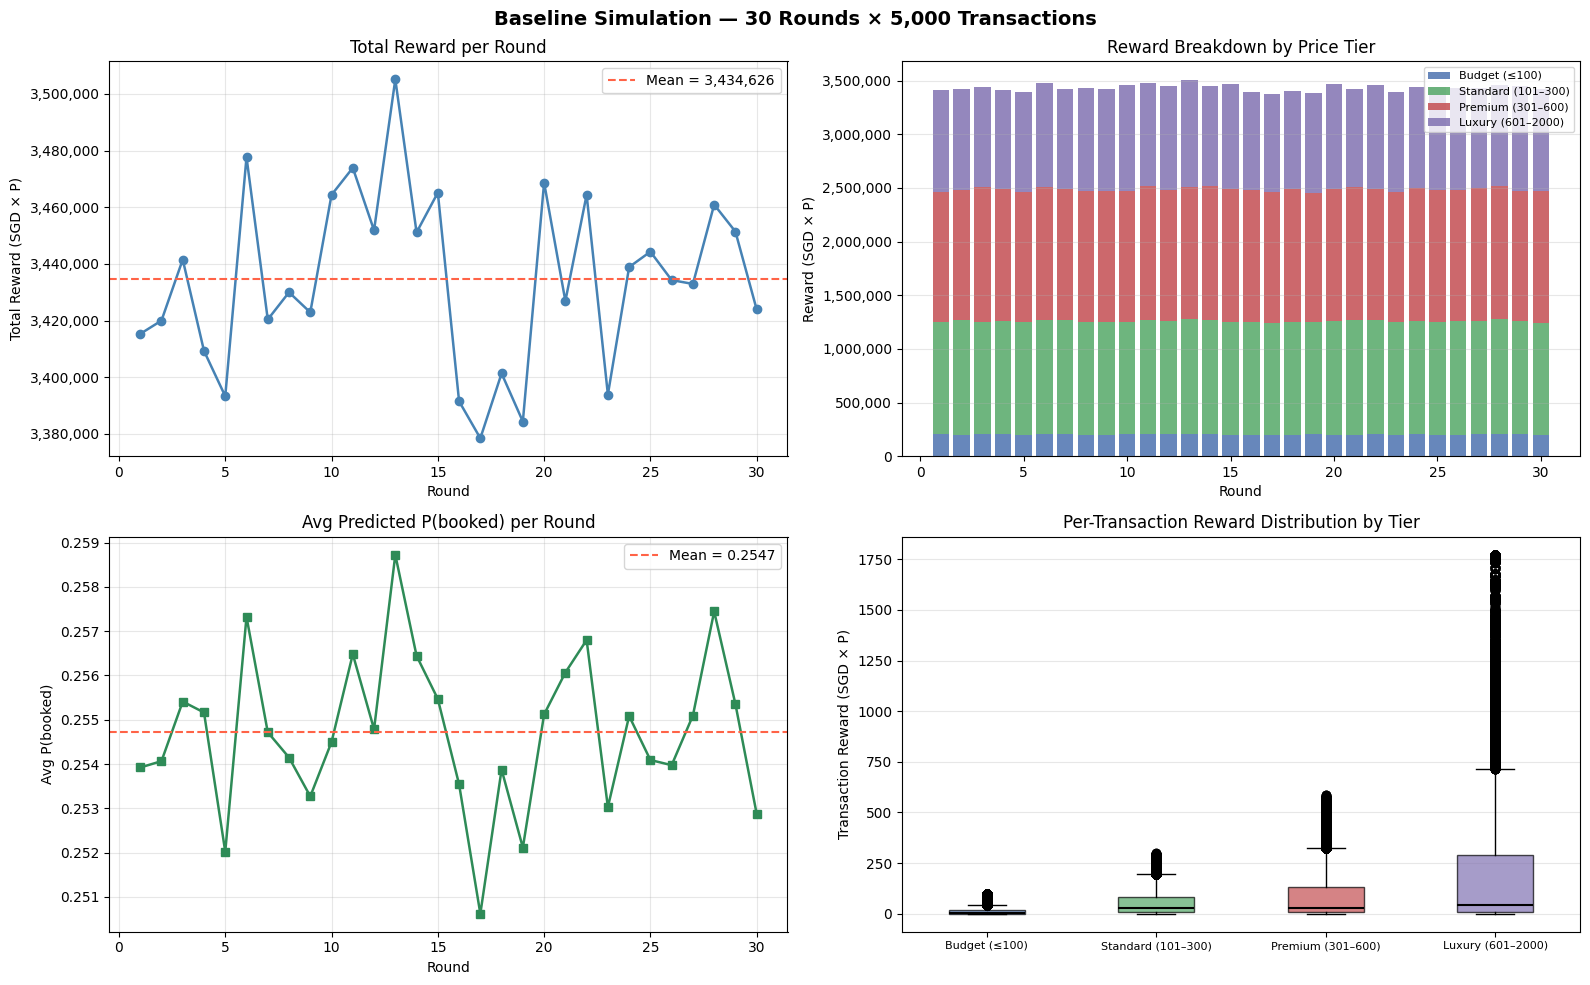

Figure saved → d:\School\msba\作业\5113\group\sg\results\baseline_simulation.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Baseline Simulation — 30 Rounds × 5,000 Transactions', fontsize=14, fontweight='bold')

rounds = results_df['round']

# ── (1) Total reward per round ────────────────────────────────────────
ax = axes[0, 0]
ax.plot(rounds, results_df['total_reward'], marker='o', color='steelblue', linewidth=1.8)
ax.axhline(results_df['total_reward'].mean(), color='tomato', linestyle='--',
           label=f'Mean = {results_df["total_reward"].mean():,.0f}')
ax.set_title('Total Reward per Round')
ax.set_xlabel('Round')
ax.set_ylabel('Total Reward (SGD × P)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.grid(alpha=0.3)

# ── (2) Reward breakdown by tier (stacked bar) ────────────────────────
ax = axes[0, 1]
bottom = np.zeros(N_ROUNDS)
for t in range(N_TIERS):
    vals = results_df[f'reward_tier_{t}'].values
    ax.bar(rounds, vals, bottom=bottom, label=TIER_LABELS[t], color=TIER_COLORS[t], alpha=0.85)
    bottom += vals
ax.set_title('Reward Breakdown by Price Tier')
ax.set_xlabel('Round')
ax.set_ylabel('Reward (SGD × P)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3, axis='y')

# ── (3) Average predicted booking probability per round ───────────────
ax = axes[1, 0]
ax.plot(rounds, results_df['avg_pred_prob'], marker='s', color='seagreen', linewidth=1.8)
ax.axhline(results_df['avg_pred_prob'].mean(), color='tomato', linestyle='--',
           label=f'Mean = {results_df["avg_pred_prob"].mean():.4f}')
ax.set_title('Avg Predicted P(booked) per Round')
ax.set_xlabel('Round')
ax.set_ylabel('Avg P(booked)')
ax.legend()
ax.grid(alpha=0.3)

# ── (4) Reward distribution per tier (box plot from full log) ─────────
ax = axes[1, 1]
tier_reward_data = [full_log[full_log['price_tier'] == t]['reward'].values for t in range(N_TIERS)]
bp = ax.boxplot(tier_reward_data, patch_artist=True, notch=False,
                medianprops={'color': 'black', 'linewidth': 1.5})
for patch, color in zip(bp['boxes'], TIER_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Per-Transaction Reward Distribution by Tier')
ax.set_xticklabels([TIER_LABELS[t] for t in range(N_TIERS)], fontsize=8)
ax.set_ylabel('Transaction Reward (SGD × P)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
fig_path = os.path.join(RESULT_DIR, 'baseline_simulation.png')
plt.savefig(fig_path, dpi=120)
plt.show()
print(f'Figure saved → {fig_path}')

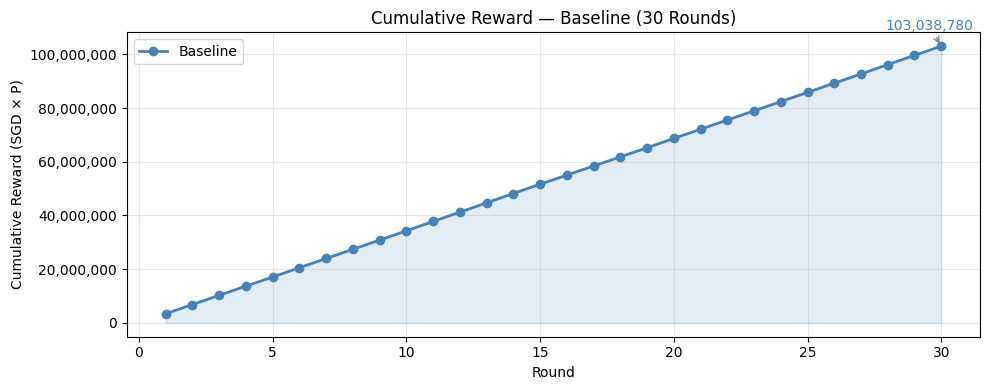

Figure saved → d:\School\msba\作业\5113\group\sg\results\baseline_cumulative.png


In [15]:
# ── Cumulative reward over rounds ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

cumulative = results_df['total_reward'].cumsum()
ax.fill_between(rounds, cumulative, alpha=0.15, color='steelblue')
ax.plot(rounds, cumulative, marker='o', color='steelblue', linewidth=2, label='Baseline')

ax.set_title('Cumulative Reward — Baseline (30 Rounds)')
ax.set_xlabel('Round')
ax.set_ylabel('Cumulative Reward (SGD × P)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.grid(alpha=0.3)

# Annotate final value
final_val = cumulative.iloc[-1]
ax.annotate(f'{final_val:,.0f}',
            xy=(rounds.iloc[-1], final_val),
            xytext=(-40, 12), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=10, color='steelblue')

plt.tight_layout()
fig_path2 = os.path.join(RESULT_DIR, 'baseline_cumulative.png')
plt.savefig(fig_path2, dpi=120)
plt.show()
print(f'Figure saved → {fig_path2}')

## 7. Save Results

In [16]:
# Save round-level summary (used by MAB notebooks for comparison)
out_path = os.path.join(RESULT_DIR, 'baseline_results.csv')
results_df.to_csv(out_path, index=False)
print(f'Round summary saved → {out_path}')

# Print key stats
print(f'\n=== Baseline Summary ===')
print(f'  Rounds              : {N_ROUNDS}')
print(f'  Transactions/round  : {N_TRANSACTIONS:,}')
print(f'  Mean reward/round   : {results_df["total_reward"].mean():>12,.1f}')
print(f'  Std  reward/round   : {results_df["total_reward"].std():>12,.1f}')
print(f'  Total cumulative    : {results_df["total_reward"].sum():>12,.1f}')
print(f'  Mean P(booked)      : {results_df["avg_pred_prob"].mean():>12.4f}')

print(f'\nPer-tier reward contribution (averaged across rounds):')
for t in range(N_TIERS):
    col  = f'reward_tier_{t}'
    mean = results_df[col].mean()
    pct  = mean / results_df['total_reward'].mean() * 100
    print(f'  Tier {t} {TIER_LABELS[t]:22s}: {mean:>9,.1f}  ({pct:.1f}%)')

Round summary saved → d:\School\msba\作业\5113\group\sg\results\baseline_results.csv

=== Baseline Summary ===
  Rounds              : 30
  Transactions/round  : 50,000
  Mean reward/round   :  3,434,626.0
  Std  reward/round   :     30,911.2
  Total cumulative    : 103,038,780.1
  Mean P(booked)      :       0.2547

Per-tier reward contribution (averaged across rounds):
  Tier 0 Budget (≤100)         : 202,607.9  (5.9%)
  Tier 1 Standard (101–300)    : 1,055,933.8  (30.7%)
  Tier 2 Premium (301–600)     : 1,226,585.4  (35.7%)
  Tier 3 Luxury (601–2000)     : 949,498.9  (27.6%)
